# Supervised Classification and Model Evaluation

**Context:** Guided classification exercises, consolidated and extended for portfolio presentation  
**Tools:** Python, pandas, scikit-learn, Matplotlib, seaborn  
**Methods:** stratified splitting, cross-validation, leakage-safe pipelines, model comparison,
confusion matrices, multiclass averaging, ROC-AUC, precision-recall analysis

## TL;DR

- On the three-class Wine dataset, five-fold cross-validation selected the RBF support
  vector machine with a mean macro F1 of **0.992**. It correctly classified **44 of 45**
  holdout observations, achieving **97.8% accuracy** and **0.976 macro F1**. The small and
  comparatively easy dataset limits how far this result should be generalised.
- On the Titanic dataset, cross-validation selected logistic regression by ROC-AUC. On an
  untouched **179-passenger** holdout set, it achieved **84.9% accuracy**, **83.4% balanced
  accuracy**, **79.7% F1**, and **0.878 ROC-AUC**.
- The Titanic confusion matrix contains **99 true negatives, 53 true positives, 11 false
  positives, and 16 false negatives**. Reporting these errors alongside aggregate metrics
  makes model behaviour more transparent.
- All learned preprocessing is fitted inside scikit-learn pipelines using training data
  only. The test sets are reserved for one final evaluation after cross-validation.

## Context & Methods

This notebook uses two case studies to demonstrate a complete supervised-classification
workflow:

1. **Wine:** compare three algorithms on a multiclass target and explain macro versus
   weighted metrics.
2. **Titanic:** build a mixed-type preprocessing pipeline, select a binary classifier by
   cross-validated ROC-AUC, and inspect its errors on untouched data.

### Key assumptions

- Class labels are available and suitable for supervised learning.
- Stratification is used so each split preserves class proportions.
- Scaling and missing-value imputation are learned inside each training fold.
- Macro metrics give every Wine class equal importance; weighted metrics also reflect class
  frequency.
- Titanic title and family features are deterministic, row-level transformations. No test
  outcome or dataset-wide target statistic is used to create them.
- Titanic results describe this historical teaching dataset only. They are not causal claims
  and should not be used to make decisions about people.

## Setup

The Wine data ships with scikit-learn. Place `titanic.csv` in this project's `data/` folder.
The raw Titanic file is excluded from GitHub because redistribution permission has not been
established.

Technical references:

- [scikit-learn: choosing an estimator](https://scikit-learn.org/stable/machine_learning_map.html)
- [scikit-learn: pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html)
- [scikit-learn: confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
- [scikit-learn: classification metrics](https://scikit-learn.org/stable/api/sklearn.metrics.html#classification-metrics)

In [1]:
from pathlib import Path
import hashlib
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_wine
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
def locate_titanic_data():
    environment_path = os.getenv("TITANIC_DATA_PATH")
    candidates = [
        Path(environment_path) if environment_path else None,
        Path("data/titanic.csv"),
        Path("supervised-classification-and-model-evaluation/data/titanic.csv"),
        Path("../supervised-classification-and-model-evaluation/data/titanic.csv"),
    ]
    for candidate in candidates:
        if candidate is not None and candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find 'titanic.csv'. Add it to this project's data/ folder."
    )


def build_models():
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=3000, random_state=RANDOM_STATE
        ),
        "RBF SVM": SVC(kernel="rbf", random_state=RANDOM_STATE),
        "Decision Tree": DecisionTreeClassifier(
            max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE
        ),
    }


cross_validator = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)

## Data

### 1. Wine: a compact multiclass benchmark

In [3]:
wine_bundle = load_wine(as_frame=True)
wine_features = wine_bundle.data.copy()
wine_target = wine_bundle.target.copy()

wine_profile = pd.Series(
    {
        "rows": len(wine_features),
        "features": wine_features.shape[1],
        "classes": wine_target.nunique(),
        "missing_cells": int(wine_features.isna().sum().sum()),
        "exact_duplicate_rows": int(wine_features.duplicated().sum()),
    },
    name="Wine dataset",
)
wine_profile.to_frame()

,Wine dataset
rows,178
features,13
classes,3
missing_cells,0
exact_duplicate_rows,0


In [4]:
wine_class_counts = (
    wine_target.value_counts()
    .sort_index()
    .rename(index=dict(enumerate(wine_bundle.target_names)))
    .rename("observations")
)
wine_class_counts.to_frame()

,observations
target,
class_0,59
class_1,71
class_2,48


The classes are not exactly equal in size. Accuracy remains useful, but macro averages are
reported so the smallest class receives the same importance as the largest. Weighted
averages are included to show the effect of class frequency.

## Results

### 2. Wine model comparison

In [5]:
wine_X_train, wine_X_test, wine_y_train, wine_y_test = train_test_split(
    wine_features,
    wine_target,
    test_size=0.25,
    stratify=wine_target,
    random_state=RANDOM_STATE,
)

wine_scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}

wine_rows = []
for model_name, estimator in build_models().items():
    candidate = Pipeline(
        [("scaler", StandardScaler()), ("model", estimator)]
    )
    scores = cross_validate(
        candidate,
        wine_X_train,
        wine_y_train,
        cv=cross_validator,
        scoring=wine_scoring,
        n_jobs=1,
    )
    row = {"model": model_name}
    for metric_name in wine_scoring:
        values = scores[f"test_{metric_name}"]
        row[f"{metric_name}_mean"] = values.mean()
        row[f"{metric_name}_std"] = values.std()
    wine_rows.append(row)

wine_cv_results = (
    pd.DataFrame(wine_rows)
    .set_index("model")
    .sort_values("f1_macro_mean", ascending=False)
)
wine_cv_results[
    [
        "accuracy_mean",
        "balanced_accuracy_mean",
        "precision_macro_mean",
        "recall_macro_mean",
        "f1_macro_mean",
        "f1_weighted_mean",
    ]
].round(4)

,accuracy_mean,balanced_accuracy_mean,precision_macro_mean,recall_macro_mean,f1_macro_mean,f1_weighted_mean
model,,,,,,
RBF SVM,0.9926,0.9939,0.9917,0.9939,0.9924,0.9927
Logistic Regression,0.9775,0.9812,0.9767,0.9812,0.9777,0.9776
Decision Tree,0.9100,0.9121,0.9225,0.9121,0.9119,0.9092


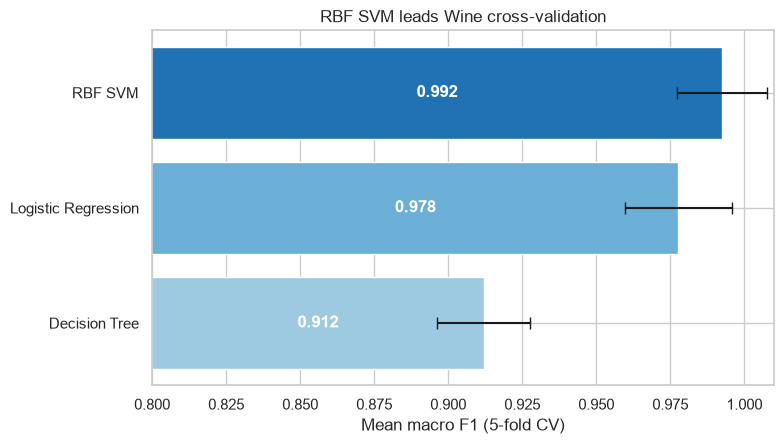

In [6]:
figure, axis = plt.subplots(figsize=(8, 4.6))
ordered_wine = wine_cv_results.sort_values("f1_macro_mean")
axis.barh(
    ordered_wine.index,
    ordered_wine["f1_macro_mean"],
    xerr=ordered_wine["f1_macro_std"],
    color=["#9ecae1", "#6baed6", "#2171b5"],
    capsize=4,
)
axis.set_xlim(0.80, 1.01)
axis.set_xlabel("Mean macro F1 (5-fold CV)")
axis.set_ylabel("")
axis.set_title("RBF SVM leads Wine cross-validation")
for position, value in enumerate(ordered_wine["f1_macro_mean"]):
    axis.text(
        (0.80 + value) / 2,
        position,
        f"{value:.3f}",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

In [7]:
selected_wine_name = wine_cv_results.index[0]
selected_wine_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", build_models()[selected_wine_name]),
    ]
)
selected_wine_model.fit(wine_X_train, wine_y_train)
wine_predictions = selected_wine_model.predict(wine_X_test)

wine_holdout_metrics = pd.Series(
    {
        "accuracy": accuracy_score(wine_y_test, wine_predictions),
        "balanced_accuracy": balanced_accuracy_score(
            wine_y_test, wine_predictions
        ),
        "precision_macro": precision_score(
            wine_y_test, wine_predictions, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            wine_y_test, wine_predictions, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            wine_y_test, wine_predictions, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            wine_y_test, wine_predictions, average="weighted", zero_division=0
        ),
    },
    name=f"{selected_wine_name} holdout",
)
wine_holdout_metrics.round(4).to_frame()

,RBF SVM holdout
accuracy,0.9778
balanced_accuracy,0.9722
precision_macro,0.9825
recall_macro,0.9722
f1_macro,0.9765
f1_weighted,0.9776


In [8]:
wine_report = pd.DataFrame(
    classification_report(
        wine_y_test,
        wine_predictions,
        target_names=wine_bundle.target_names,
        output_dict=True,
        zero_division=0,
    )
).T
wine_report.round(3)

,precision,recall,f1-score,support
class_0,1.000,1.000,1.000,15.000
class_1,0.947,1.000,0.973,18.000
class_2,1.000,0.917,0.957,12.000
accuracy,0.978,0.978,0.978,0.978
macro avg,0.982,0.972,0.976,45.000
weighted avg,0.979,0.978,0.978,45.000


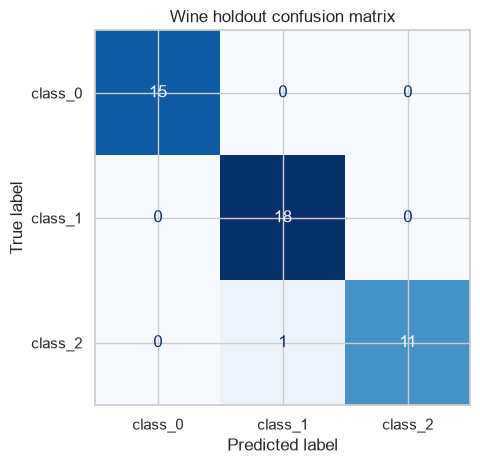

In [9]:
figure, axis = plt.subplots(figsize=(5.8, 4.8))
ConfusionMatrixDisplay.from_predictions(
    wine_y_test,
    wine_predictions,
    display_labels=wine_bundle.target_names,
    cmap="Blues",
    colorbar=False,
    ax=axis,
)
axis.set_title("Wine holdout confusion matrix")
plt.tight_layout()
plt.show()

The selected RBF SVM classifies 44 of 45 holdout observations correctly; one `class_2`
observation is predicted as `class_1`. This is consistent with the very high
cross-validation results, but performance on a small teaching dataset should not be assumed
to transfer unchanged to new populations or measurement conditions.

### 3. Titanic data preparation

In [10]:
titanic_path = locate_titanic_data()
titanic_raw = pd.read_csv(titanic_path)
titanic_sha256 = hashlib.sha256(titanic_path.read_bytes()).hexdigest()

expected_titanic_columns = {
    "PassengerId", "Survived", "Pclass", "Name", "Sex", "Age", "SibSp",
    "Parch", "Ticket", "Fare", "Cabin", "Embarked"
}
assert set(titanic_raw.columns) == expected_titanic_columns
assert set(titanic_raw["Survived"].unique()) == {0, 1}

titanic_profile = pd.Series(
    {
        "rows": len(titanic_raw),
        "columns": titanic_raw.shape[1],
        "missing_cells": int(titanic_raw.isna().sum().sum()),
        "exact_duplicate_rows": int(titanic_raw.duplicated().sum()),
        "survival_rate_pct": 100 * titanic_raw["Survived"].mean(),
    },
    name="Titanic dataset",
)
print(f"SHA-256: {titanic_sha256}")
titanic_profile.round(2).to_frame()

SHA-256: 7d118fef8b6ccf7f81111877bc388536f7b1e498a655e3d649d19aaa010e9f6f


,Titanic dataset
rows,891.00
columns,12.00
missing_cells,866.00
exact_duplicate_rows,0.00
survival_rate_pct,38.38


In [11]:
titanic_missing = (
    titanic_raw.isna()
    .sum()
    .loc[lambda values: values.gt(0)]
    .sort_values(ascending=False)
    .rename("missing_rows")
    .to_frame()
)
titanic_missing["missing_pct"] = (
    100 * titanic_missing["missing_rows"] / len(titanic_raw)
)
titanic_missing.round(1)

,missing_rows,missing_pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


In [12]:
def extract_title(passenger_name):
    match = re.search(r",\s*([^.]*)\.", passenger_name)
    title = match.group(1).strip() if match else "Unknown"
    return title if title in {"Mr", "Miss", "Mrs", "Master"} else "Rare"


def create_titanic_features(frame):
    family_size = frame["SibSp"] + frame["Parch"] + 1
    return pd.DataFrame(
        {
            "Pclass": frame["Pclass"].astype(str),
            "Sex": frame["Sex"],
            "Age": frame["Age"],
            "SibSp": frame["SibSp"],
            "Parch": frame["Parch"],
            "Fare": frame["Fare"],
            "Embarked": frame["Embarked"],
            "Title": frame["Name"].map(extract_title),
            "FamilySize": family_size,
            "IsAlone": (family_size == 1).astype(int),
        },
        index=frame.index,
    )


titanic_features = create_titanic_features(titanic_raw)
titanic_target = titanic_raw["Survived"].copy()

titanic_feature_summary = pd.DataFrame(
    {
        "dtype": titanic_features.dtypes.astype(str),
        "missing": titanic_features.isna().sum(),
        "unique_values": titanic_features.nunique(dropna=True),
    }
)
titanic_feature_summary

,dtype,missing,unique_values
Pclass,object,0,3
Sex,object,0,2
Age,float64,177,88
SibSp,int64,0,7
Parch,int64,0,7
Fare,float64,0,248
Embarked,object,2,3
Title,object,0,5
FamilySize,int64,0,9
IsAlone,int64,0,2


`PassengerId`, raw `Name`, `Ticket`, and `Cabin` are excluded. The passenger title is
extracted into five predefined groups, while family size and travelling-alone status are
derived without using the target. Missing `Age` and `Embarked` values are retained here and
will be imputed inside each training fold.

### 4. Titanic model comparison

In [13]:
titanic_numeric_columns = [
    "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone"
]
titanic_categorical_columns = ["Pclass", "Sex", "Embarked", "Title"]

titanic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            titanic_numeric_columns,
        ),
        (
            "categorical",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            titanic_categorical_columns,
        ),
    ]
)

titanic_X_train, titanic_X_test, titanic_y_train, titanic_y_test = train_test_split(
    titanic_features,
    titanic_target,
    test_size=0.20,
    stratify=titanic_target,
    random_state=RANDOM_STATE,
)

split_distribution = pd.DataFrame(
    {
        "full": titanic_target.value_counts().sort_index(),
        "train": titanic_y_train.value_counts().sort_index(),
        "test": titanic_y_test.value_counts().sort_index(),
    }
)
split_distribution.index = ["Did not survive", "Survived"]
split_distribution

,full,train,test
Did not survive,549,439,110
Survived,342,273,69


In [14]:
titanic_scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

titanic_rows = []
for model_name, estimator in build_models().items():
    candidate = Pipeline(
        [("preprocessor", titanic_preprocessor), ("model", estimator)]
    )
    scores = cross_validate(
        candidate,
        titanic_X_train,
        titanic_y_train,
        cv=cross_validator,
        scoring=titanic_scoring,
        n_jobs=1,
    )
    row = {"model": model_name}
    for metric_name in titanic_scoring:
        values = scores[f"test_{metric_name}"]
        row[f"{metric_name}_mean"] = values.mean()
        row[f"{metric_name}_std"] = values.std()
    titanic_rows.append(row)

titanic_cv_results = (
    pd.DataFrame(titanic_rows)
    .set_index("model")
    .sort_values("roc_auc_mean", ascending=False)
)
titanic_cv_results[
    [
        "accuracy_mean", "balanced_accuracy_mean", "precision_mean",
        "recall_mean", "f1_mean", "roc_auc_mean"
    ]
].round(4)

,accuracy_mean,balanced_accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
model,,,,,,
Logistic Regression,0.8231,0.8081,0.7867,0.7437,0.7633,0.8661
RBF SVM,0.8287,0.8091,0.8092,0.7252,0.7643,0.8493
Decision Tree,0.8048,0.7809,0.7965,0.6778,0.7258,0.8469


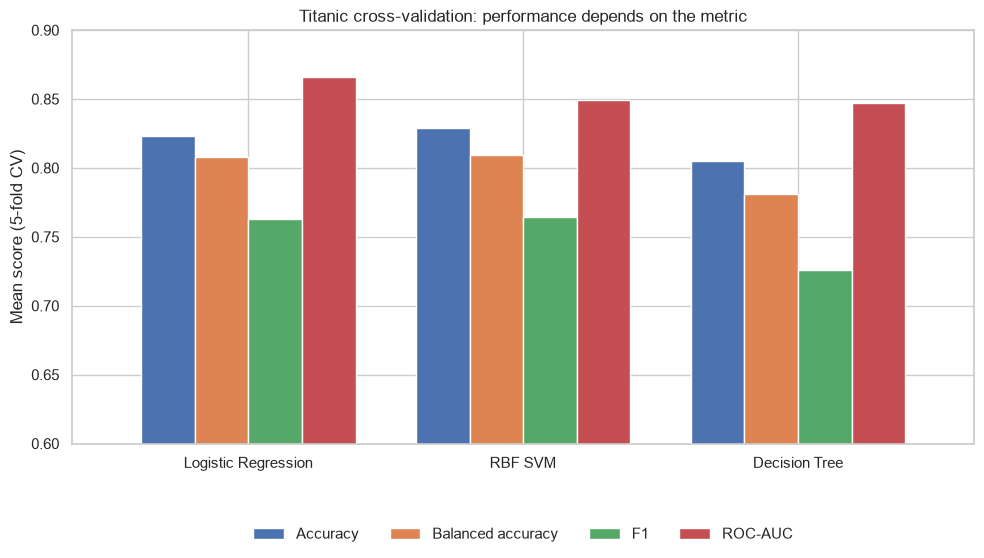

In [15]:
metrics_to_plot = [
    "accuracy_mean", "balanced_accuracy_mean", "f1_mean", "roc_auc_mean"
]
plot_labels = ["Accuracy", "Balanced accuracy", "F1", "ROC-AUC"]
plot_frame = titanic_cv_results[metrics_to_plot].copy()
plot_frame.columns = plot_labels

axis = plot_frame.plot(kind="bar", figsize=(10, 5.8), width=0.78)
axis.set_ylim(0.60, 0.90)
axis.set_xlabel("")
axis.set_ylabel("Mean score (5-fold CV)")
axis.set_title("Titanic cross-validation: performance depends on the metric")
axis.legend(
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.17),
    frameon=False,
)
axis.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

In [16]:
selected_titanic_name = titanic_cv_results.index[0]
selected_titanic_model = Pipeline(
    [
        ("preprocessor", titanic_preprocessor),
        ("model", build_models()[selected_titanic_name]),
    ]
)
selected_titanic_model.fit(titanic_X_train, titanic_y_train)

titanic_predictions = selected_titanic_model.predict(titanic_X_test)
titanic_scores = selected_titanic_model.decision_function(titanic_X_test)

titanic_holdout_metrics = pd.Series(
    {
        "accuracy": accuracy_score(titanic_y_test, titanic_predictions),
        "balanced_accuracy": balanced_accuracy_score(
            titanic_y_test, titanic_predictions
        ),
        "precision": precision_score(titanic_y_test, titanic_predictions),
        "recall": recall_score(titanic_y_test, titanic_predictions),
        "f1": f1_score(titanic_y_test, titanic_predictions),
        "roc_auc": roc_auc_score(titanic_y_test, titanic_scores),
        "average_precision": average_precision_score(
            titanic_y_test, titanic_scores
        ),
    },
    name=f"{selected_titanic_name} holdout",
)
titanic_holdout_metrics.round(4).to_frame()

,Logistic Regression holdout
accuracy,0.8492
balanced_accuracy,0.8341
precision,0.8281
recall,0.7681
f1,0.7970
roc_auc,0.8779
average_precision,0.8429


In [17]:
titanic_report = pd.DataFrame(
    classification_report(
        titanic_y_test,
        titanic_predictions,
        target_names=["Did not survive", "Survived"],
        output_dict=True,
        zero_division=0,
    )
).T
titanic_report.round(3)

,precision,recall,f1-score,support
Did not survive,0.861,0.900,0.880,110.000
Survived,0.828,0.768,0.797,69.000
accuracy,0.849,0.849,0.849,0.849
macro avg,0.844,0.834,0.838,179.000
weighted avg,0.848,0.849,0.848,179.000


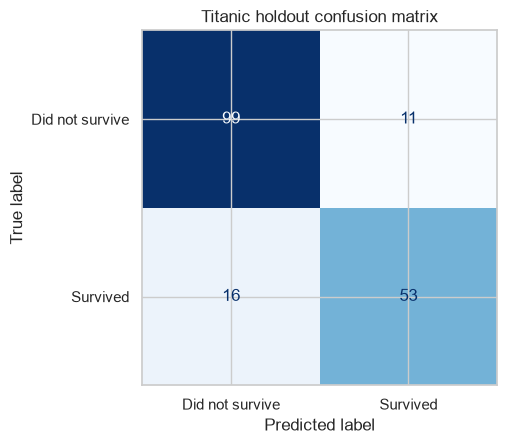

In [18]:
figure, axis = plt.subplots(figsize=(5.6, 4.6))
ConfusionMatrixDisplay.from_predictions(
    titanic_y_test,
    titanic_predictions,
    display_labels=["Did not survive", "Survived"],
    cmap="Blues",
    colorbar=False,
    ax=axis,
)
axis.set_title("Titanic holdout confusion matrix")
plt.tight_layout()
plt.show()

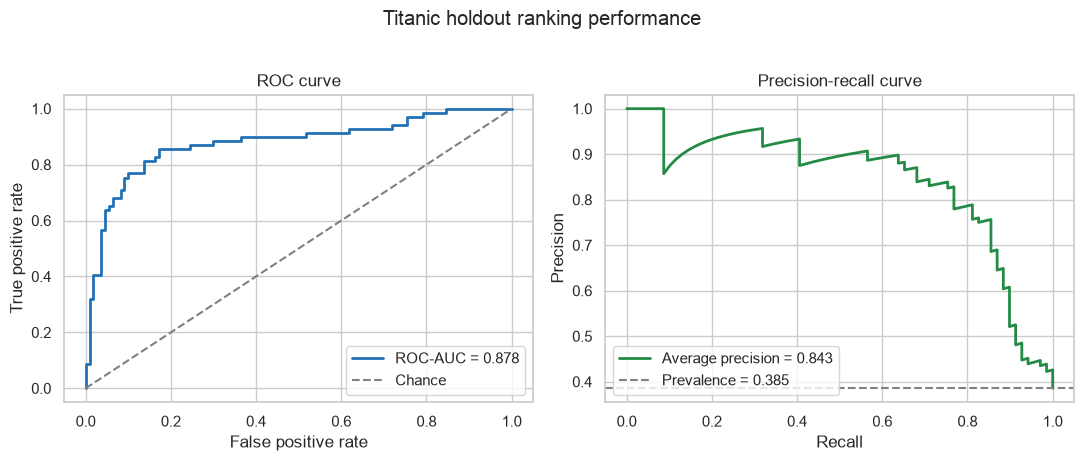

In [19]:
false_positive_rate, true_positive_rate, _ = roc_curve(
    titanic_y_test, titanic_scores
)
precision_curve, recall_curve, _ = precision_recall_curve(
    titanic_y_test, titanic_scores
)
prevalence = titanic_y_test.mean()

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(
    false_positive_rate,
    true_positive_rate,
    color="#2171b5",
    linewidth=2,
    label=f"ROC-AUC = {titanic_holdout_metrics['roc_auc']:.3f}",
)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve")
axes[0].legend(loc="lower right")

axes[1].plot(
    recall_curve,
    precision_curve,
    color="#238b45",
    linewidth=2,
    label=f"Average precision = {titanic_holdout_metrics['average_precision']:.3f}",
)
axes[1].axhline(
    prevalence,
    linestyle="--",
    color="grey",
    label=f"Prevalence = {prevalence:.3f}",
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve")
axes[1].legend(loc="lower left")

figure.suptitle("Titanic holdout ranking performance", y=1.02)
plt.tight_layout()
plt.show()

### 5. Interpret the selected Titanic model cautiously

In [20]:
transformed_feature_names = (
    selected_titanic_model.named_steps["preprocessor"].get_feature_names_out()
)
coefficients = pd.Series(
    selected_titanic_model.named_steps["model"].coef_[0],
    index=transformed_feature_names,
    name="coefficient",
)
coefficient_extremes = pd.concat(
    [coefficients.nsmallest(6), coefficients.nlargest(6)]
).sort_values()
coefficient_extremes.round(3).to_frame()

,coefficient
categorical__Title_Mr,-1.159
categorical__Pclass_3,-0.961
categorical__Sex_male,-0.899
categorical__Title_Rare,-0.432
numeric__Age,-0.370
numeric__SibSp,-0.348
numeric__Fare,0.156
categorical__Embarked_Q,0.300
categorical__Title_Mrs,0.382
categorical__Sex_female,0.903


Logistic-regression coefficients describe associations after preprocessing; they do not
establish that changing a passenger characteristic would have changed the historical
outcome. Their magnitudes also depend on scaling, reference categories, correlated features,
and this specific dataset.

## Checks

In [21]:
assert len(wine_X_train) + len(wine_X_test) == len(wine_features)
assert len(titanic_X_train) + len(titanic_X_test) == len(titanic_features)
assert set(wine_X_train.index).isdisjoint(wine_X_test.index)
assert set(titanic_X_train.index).isdisjoint(titanic_X_test.index)
assert selected_wine_name == "RBF SVM"
assert selected_titanic_name == "Logistic Regression"
assert confusion_matrix(wine_y_test, wine_predictions).sum() == len(wine_y_test)
assert confusion_matrix(titanic_y_test, titanic_predictions).sum() == len(
    titanic_y_test
)
assert "Survived" not in titanic_features.columns
assert not {"PassengerId", "Name", "Ticket", "Cabin"}.intersection(
    titanic_features.columns
)
assert np.isfinite(titanic_holdout_metrics).all()
print("All integrity, split, selection, and metric checks passed.")

All integrity, split, selection, and metric checks passed.


## Takeaways

- **Model evaluation needs more than accuracy.** Confusion matrices and class-sensitive
  metrics reveal which outcomes a model misses.
- **Averaging choice matters in multiclass work.** Macro metrics weight each class equally;
  weighted metrics give larger classes more influence.
- **Preprocessing belongs inside the pipeline.** This prevents validation and test data from
  influencing learned medians, scales, and category encodings.
- **Model selection and final evaluation serve different purposes.** Cross-validation on the
  training partition chooses the model; the untouched holdout estimates its performance once.
- **Near-perfect scores require restraint.** Wine's 44-of-45 holdout result is encouraging,
  but the small benchmark does not justify a claim of universal performance.

### Possible extensions

- Tune hyperparameters using nested or repeated cross-validation.
- Add calibration analysis when predicted probabilities drive decisions.
- Test performance stability across relevant Titanic subgroups while treating the historical
  and ethical limitations explicitly.